# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Hafizh Iman Wicaksono
- **Email:** hafizhimanwicaksono@gmail.com
- **ID Dicoding:** hafizhiman

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren rata-rata bulanan konsentrasi polutan PM2.5 dari seluruh stasiun pemantauan di Beijing selama periode 2013 hingga 2017, dan pada bulan apa tingkat polusi mencapai titik tertinggi?
- **Pertanyaan 2:** Stasiun pemantauan mana yang mencatat rata-rata tingkat polusi PM2.5 tertinggi dan terendah secara keseluruhan, dan bagaimana perbandingannya?
- **Pertanyaan 3:** Bagaimana korelasi antara faktor meteorologi (kecepatan angin/WSPM dan curah hujan/RAIN) terhadap konsentrasi PM2.5, dan stasiun mana yang mencatat kualitas udara terbaik berkat faktor cuaca tersebut selama periode 2013-2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import datetime

# Mengatur style visualisasi
sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
path = 'data/*.csv'
all_files = glob.glob(path)

# Membaca dan menggabungkan semua file CSV menjadi satu DataFrame
df_list = [pd.read_csv(file) for file in all_files]
main_df = pd.concat(df_list, ignore_index=True)

main_df.head(50000)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,14932,2014,11,13,3,6.0,18.0,4.0,33.0,400.0,29.0,1.9,1018.0,-12.3,0.0,WNW,0.4,Gucheng
49996,14933,2014,11,13,4,5.0,7.0,2.0,36.0,400.0,25.0,0.6,1018.0,-11.5,0.0,W,1.0,Gucheng
49997,14934,2014,11,13,5,15.0,22.0,5.0,62.0,700.0,6.0,-0.5,1017.0,-10.7,0.0,SE,0.9,Gucheng
49998,14935,2014,11,13,6,20.0,33.0,5.0,58.0,900.0,6.0,-0.1,1017.0,-11.5,0.0,NW,0.5,Gucheng


**Insight:** (Opsional)
- Dataset berhasil digabungkan dari 12 stasiun pemantauan yang berbeda.
- Data memiliki struktur kolom temporal yang terpisah (`year`, `month`, `day`, `hour`) yang nantinya perlu disatukan menjadi format `datetime` untuk mempermudah analisis *time-series*.
- Fitur Polutan Udara (Variabel Utama): Terdapat 6 kolom yang merekam tingkat konsentrasi senyawa kimia dan partikel berbahaya di udara. Kolom polutan tersebut meliputi:
  1. PM2.5 dan PM10: Partikel debu halus
  2. SO2: Sulfur Dioksida
  3. NO2: Nitrogen Dioksida
  4. CO: Karbon Monoksida.
  5. O3: Ozon permukaan.
- Fitur Kondisi Cuaca (Meteorologi): Terdapat 6 kolom pendukung yang merekam kondisi alam saat observasi, yaitu TEMP (Suhu Udara), PRES (Tekanan Udara), DEWP (Titik Embun/Tingkat Kelembapan), RAIN (Curah Hujan), wd (Arah Angin), dan WSPM (Kecepatan Angin).



### Assessing Data

#### Identifying ... problem

In [3]:
# Melihat informasi umum data (tipe data dan jumlah baris)
print("Informasi Dataset:")
main_df.info()

print("\nJumlah Missing Values:")
print(main_df.isna().sum())

print("\nJumlah Duplikasi Data:", main_df.duplicated().sum())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB

Jumlah Missing Values:
No

**Insight:** (Opsional)
- **Volume Data Besar:** Dataset berhasil digabungkan dengan total 420.768 baris data dan 18 kolom tanpa ada satu pun data yang terduplikasi (Jumlah Duplikasi Data: 0).

- **Masalah Missing Values (Nilai Kosong):** Terdapat missing values yang cukup signifikan pada kolom polutan. Gas Karbon Monoksida (CO) memiliki data kosong terbanyak (20.701 baris), disusul oleh O3, NO2, SO2, PM2.5, dan PM10. Fitur cuaca (seperti TEMP, PRES, RAIN) juga memiliki nilai kosong namun jumlahnya relatif kecil (di bawah 500 baris), kecuali arah angin (wd) yang mencapai 1.822 baris kosong.

- **Tipe Data Kurang Tepat:** Kolom penunjuk waktu (year, month, day, hour) masih terpisah dalam format int64. Ini kurang ideal untuk kebutuhan eksplorasi data time-series. Selain itu, terdapat kolom No yang hanya berfungsi sebagai indeks dan tidak memiliki nilai analitis.

**Steps to Take:**
- **Penanganan Missing Values pada Data Numerik:** Mengingat data ini sangat krusial untuk analisis kualitas lingkungan secara kronologis, menghapus baris (drop) yang kosong akan merusak pola tren waktu. Tindakan yang akan diambil adalah melakukan **imputasi menggunakan metode interpolasi linear** pada kolom polutan dan cuaca numerik, sehingga nilai yang kosong dapat diisi berdasarkan tren nilai sebelum dan sesudahnya.

- **Penanganan Missing Values pada Data Kategorikal:** Untuk kolom arah angin (wd) yang bertipe object, nilai kosong akan diisi menggunakan nilai yang paling sering muncul (modus).

- **Penyesuaian Tipe Data (Formatting)**: Menggabungkan kolom year, month, day, dan hour menjadi satu kolom baru bertipe datetime untuk mempermudah proses agregasi dan visualisasi berbasis waktu ke depannya.

- **Menghapus Kolom Tidak Penting:** Menghapus (drop) kolom No karena DataFrame pandas sudah memiliki indeks bawaan.

### Cleaning Data

#### Fixing ... problem

In [4]:
# 1. Menghapus kolom 'No'
main_df.drop(columns=['No'], inplace=True)

# 2. Menggabungkan year, month, day, hour menjadi satu kolom datetime
main_df['datetime'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])

# 3. Mengisi missing values pada kolom numerik dengan interpolasi linear
cols_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
main_df[cols_to_interpolate] = main_df[cols_to_interpolate].interpolate(method='linear', limit_direction='both')

# 4. Mengisi missing values pada kolom kategorikal (wd - wind direction) dengan modus
main_df['wd'].fillna(main_df['wd'].mode()[0], inplace=True)

# 5. Cek kembali missing values
print("Sisa Missing Values:\n", main_df.isna().sum())

Sisa Missing Values:
 year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


/tmp/ipykernel_7678/1002028640.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  main_df['wd'].fillna(main_df['wd'].mode()[0], inplace=True)


**Insight:** (Opsional)
- Proses pembersihan data telah berhasil dilakukan. Saat ini, sudah tidak ada lagi missing values (nilai kosong) pada seluruh kolom dataset, baik pada fitur numerik (polutan dan cuaca) maupun kategorikal.

- Kolom penunjuk waktu (year, month, day, hour) telah terintegrasi dengan baik ke dalam satu kolom baru bernama datetime.

- Kolom No yang bertindak sebagai indeks redundan telah dihapus.

- Dataset kini sudah dalam kondisi yang bersih, terstruktur dengan baik, dan siap untuk dieksplorasi lebih lanjut pada tahap Exploratory Data Analysis (EDA) dan visualisasi.

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# Eksplorasi 1: Tren bulanan PM2.5 rata-rata seluruh stasiun
monthly_pm25 = main_df.groupby('month')['PM2.5'].mean().reset_index()

display(monthly_pm25)

# Eksplorasi 2: Rata-rata PM2.5 berdasarkan stasiun
station_pm25 = main_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()

display(station_pm25)

# Eksplorasi 3: Rata-rata PM2.5, Kecepatan Angin (WSPM), dan Curah Hujan (RAIN) per stasiun
weather_impact = main_df.groupby('station')[['PM2.5', 'WSPM', 'RAIN']].mean().reset_index()

# Mengurutkan berdasarkan WSPM (Kecepatan Angin) tertinggi
weather_impact_sorted = weather_impact.sort_values(by='WSPM', ascending=False)
display(weather_impact_sorted)

# Mengecek korelasi kotor (Pearson Correlation)
print("\nKorelasi antara Cuaca dan Polusi:")
print(main_df[['PM2.5', 'WSPM', 'RAIN']].corr())


,month,PM2.5
0,1,93.760559
1,2,89.213391
2,3,94.594295
3,4,73.367153
4,5,63.541148
5,6,68.837547
6,7,71.401115
7,8,53.465479
8,9,61.281071
9,10,91.715859


,station,PM2.5
0,Dongsi,86.144243
1,Nongzhanguan,85.079472
2,Wanshouxigong,85.067548
3,Gucheng,84.074802
4,Wanliu,83.467612
5,Guanyuan,82.897522
6,Aotizhongxin,82.540623
7,Tiantan,82.033097
8,Shunyi,79.437962
9,Changping,70.986438


,station,PM2.5,WSPM,RAIN
3,Dongsi,86.144243,1.860815,0.063983
7,Nongzhanguan,85.079472,1.860815,0.063983
9,Tiantan,82.033097,1.860815,0.063983
1,Changping,70.986438,1.854871,0.060293
2,Dingling,66.845557,1.854871,0.060293
8,Shunyi,79.437962,1.807784,0.061010
11,Wanshouxigong,85.067548,1.745450,0.064285
0,Aotizhongxin,82.540623,1.708577,0.067383
4,Guanyuan,82.897522,1.708577,0.067383
6,Huairou,69.501747,1.652772,0.067950



Korelasi antara Cuaca dan Polusi:
          PM2.5      WSPM      RAIN
PM2.5  1.000000 -0.271425 -0.014452
WSPM  -0.271425  1.000000  0.020975
RAIN  -0.014452  0.020975  1.000000


**Insight:** (Opsional)
- **Pola Musiman Polusi (Eksplorasi 1):** Terdapat fluktuasi yang signifikan pada rata-rata konsentrasi PM2.5 tiap bulannya. Tingkat polusi terburuk terjadi pada bulan Desember (mencapai puncaknya di 103.68 µg/m³), Maret (94.59 µg/m³), dan Januari (93.76 µg/m³). Sebaliknya, kualitas udara paling bersih (PM2.5 terendah) tercatat pada bulan Agustus (53.46 µg/m³). Hal ini mengindikasikan bahwa periode musim dingin (akhir dan awal tahun) sangat rentan terhadap lonjakan polusi udara parah.

- **Distribusi Polusi Berdasarkan Lokasi (Eksplorasi 2):** Stasiun Dongsi menempati urutan pertama sebagai area dengan tingkat polusi rata-rata tertinggi (86.14 µg/m³), disusul oleh Nongzhanguan dan Wanshouxigong. Di sisi lain, stasiun Dingling mencatat kualitas udara rata-rata terbaik dengan PM2.5 terendah (66.85 µg/m³), diikuti oleh stasiun Huairou (69.50 µg/m³). Perbedaan ini menunjukkan adanya kesenjangan kualitas udara antar wilayah pemantauan.

- **Pengaruh Faktor Meteorologi (Eksplorasi 3):** Dari matriks korelasi, terlihat adanya **korelasi negatif (-0.27)** antara PM2.5 dan Kecepatan Angin (WSPM). Ini membuktikan secara matematis bahwa peningkatan kecepatan angin berbanding terbalik dengan tingkat polusi; semakin kencang angin, polutan PM2.5 cenderung tersapu dan menurun. **Curah Hujan (RAIN)** memiliki **korelasi negatif yang sangat lemah** **(-0.01)** terhadap PM2.5. Hal ini menunjukkan bahwa secara keseluruhan, tingkat curah hujan tidak memiliki hubungan linear yang signifikan dalam menekan konsentrasi PM2.5 pada dataset ini.





## Visualization & Explanatory Analysis

### Pertanyaan 1:

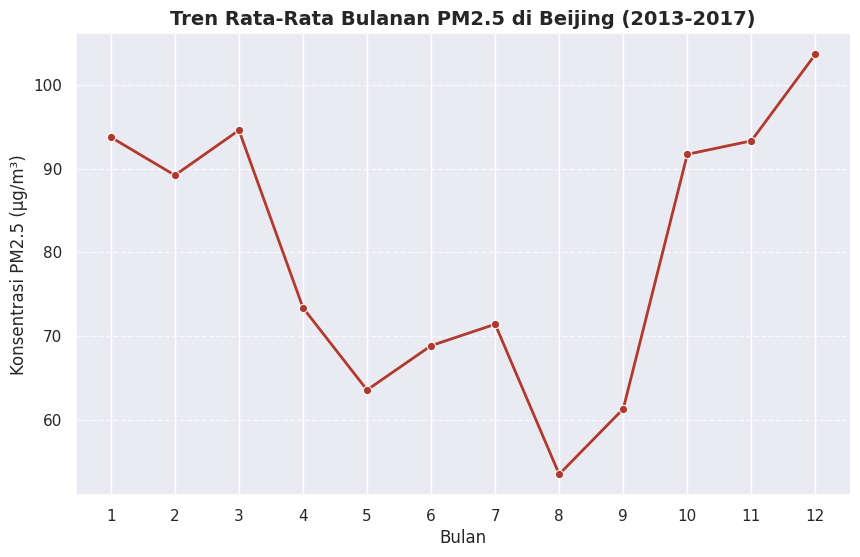

In [6]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_pm25, x='month', y='PM2.5', marker='o', linewidth=2, color='#b03a2e')

plt.title('Tren Rata-Rata Bulanan PM2.5 di Beijing (2013-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_7678/612037420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=station_pm25, x='PM2.5', y='station', palette=colors)


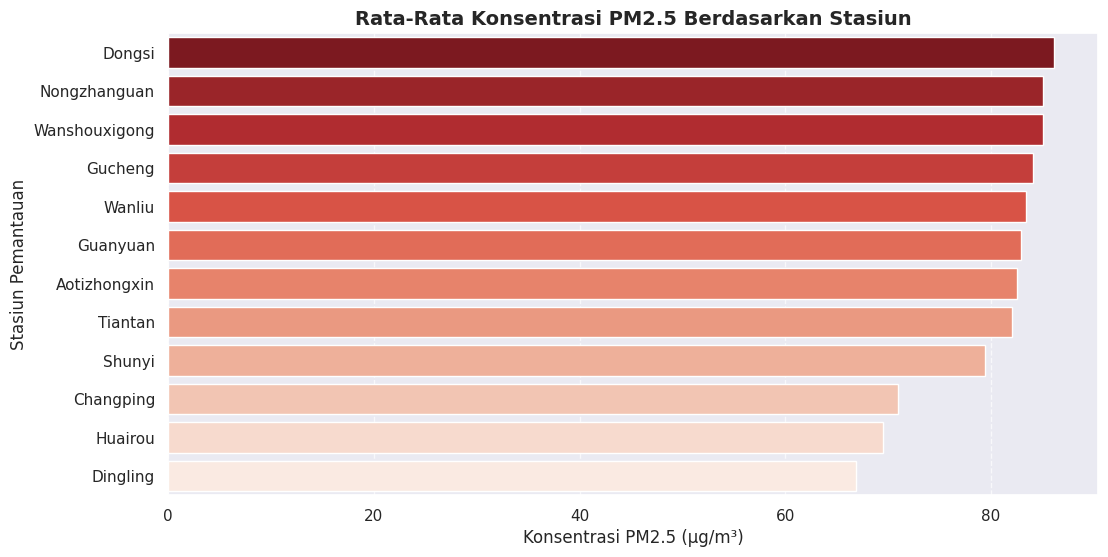

In [7]:
plt.figure(figsize=(12, 6))
# Menggunakan palet warna untuk membedakan intensitas
colors = sns.color_palette("Reds_r", len(station_pm25))

sns.barplot(data=station_pm25, x='PM2.5', y='station', palette=colors)

plt.title('Rata-Rata Konsentrasi PM2.5 Berdasarkan Stasiun', fontsize=14, fontweight='bold')
plt.xlabel('Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.ylabel('Stasiun Pemantauan', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 3:

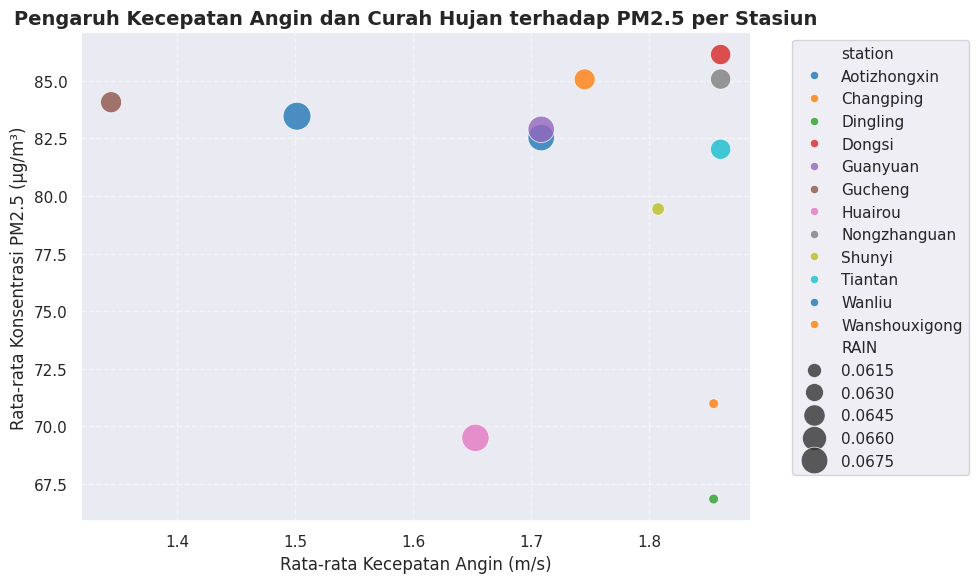

In [8]:
plt.figure(figsize=(10, 6))

# Scatter plot: sumbu X = Kecepatan Angin, sumbu Y = PM2.5
# Ukuran bubble (s) = Curah Hujan (dikali skala agar terlihat jelas)
sns.scatterplot(
    data=weather_impact,
    x='WSPM',
    y='PM2.5',
    hue='station',
    size='RAIN',
    sizes=(50, 400),
    alpha=0.8,
    palette='tab10'
)

plt.title('Pengaruh Kecepatan Angin dan Curah Hujan terhadap PM2.5 per Stasiun', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Kecepatan Angin (m/s)', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=12)

# Memindahkan legend ke luar grafik agar tidak menutupi data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
1. **Insight Visualisasi 1: Tren Rata-Rata Bulanan PM2.5**
- Pola Musiman yang Ekstrem: Terdapat pola kurva berbentuk huruf "U" yang sangat jelas. Kualitas udara memburuk secara drastis saat memasuki musim dingin (November hingga Maret), dengan puncak polusi tertinggi terjadi pada bulan Desember (menyentuh angka rata-rata di atas 100 µg/m³).

- Sebaliknya, tingkat PM2.5 turun perlahan dan mencapai titik terendah (paling bersih) pada bulan Agustus di pertengahan musim panas.

- Dugaan Penyebab: Lonjakan ekstrem di akhir dan awal tahun ini kemungkinan besar didorong oleh peningkatan masif pembakaran batu bara atau bahan bakar fosil lainnya untuk pemanas ruangan selama puncak musim dingin, ditambah dengan kondisi udara dingin yang membuat polutan terperangkap di dekat permukaan tanah.

2. **Insight Visualisasi 2: Rata-Rata PM2.5 Berdasarkan Stasiun**
- Zona Merah Polusi: Stasiun Dongsi, Nongzhanguan, dan Wanshouxigong memimpin sebagai wilayah dengan tingkat polusi terparah. Wilayah-wilayah ini perlu mendapat pengawasan lingkungan yang lebih ketat, terutama terkait emisi industri dan lalu lintas kendaraan bermotor.

- Zona Hijau: Di sisi lain spektrum, stasiun Dingling, Huairou, dan Changping mencatat tingkat PM2.5 terendah. Ini menunjukkan adanya disparitas kualitas udara yang cukup jauh, kemungkinan karena ketiga stasiun ini berada di area suburban/pinggiran kota atau dekat dengan ruang terbuka hijau yang minim aktivitas industri berat.

3. **Insight Visualisasi 3: Pengaruh Cuaca terhadap PM2.5**
- Korelasi Negatif Angin dan Polusi: Secara umum, grafik scatter plot memvalidasi korelasi negatif antara kecepatan angin dan polusi. Stasiun dengan angin lemah seperti Gucheng (kiri) memiliki PM2.5 yang tinggi, sedangkan stasiun dengan angin kencang seperti Dingling (kanan bawah) memiliki PM2.5 yang jauh lebih rendah. Angin kencang bertindak sebagai "ventilasi alam" yang mengusir partikel PM2.5.

- Anomali Menarik (Outlier): Terdapat temuan yang sangat penting pada stasiun Dongsi dan Nongzhanguan (titik merah dan abu-abu di kanan atas). Meskipun kedua stasiun ini memiliki rata-rata kecepatan angin yang tinggi (sekitar 1.86 m/s), tingkat PM2.5 mereka tetap yang tertinggi. Hal ini mengindikasikan bahwa volume sumber polutan (emisi) di area tersebut sangatlah masif, sehingga sirkulasi angin alami pun tidak sanggup menetralisir polusi udara di sana.

- Faktor Hujan: Ukuran gelembung (bubble) yang merepresentasikan curah hujan terlihat relatif seragam dan tidak membentuk pola yang tajam, mempertegas bahwa rata-rata curah hujan bukan faktor penentu utama perbedaan tingkat polusi antar stasiun dalam jangka panjang.

## Analisis Lanjutan (Opsional)
## Analisis Lanjutan: Clustering (Binning) Kualitas Udara
Tujuan dari analisis lanjutan ini adalah mengelompokkan (binning) tingkat konsentrasi PM2.5 ke dalam kategori Indeks Kualitas Udara (AQI) yang lebih mudah dipahami oleh masyarakat umum, sehingga memudahkan pengambilan kebijakan lingkungan.

In [9]:
# Membuat fungsi untuk mengkategorikan PM2.5 (Standar EPA)
def categorize_pm25(pm):
    if pm <= 50:
        return 'Good'
    elif pm <= 100:
        return 'Moderate'
    elif pm <= 150:
        return 'Unhealthy for Sensitive'
    elif pm <= 200:
        return 'Unhealthy'
    elif pm <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# Menerapkan fungsi ke kolom baru
main_df['AQI_Category'] = main_df['PM2.5'].apply(categorize_pm25)

# Melihat distribusi kategori
aqi_distribution = main_df['AQI_Category'].value_counts().reset_index()
aqi_distribution.columns = ['Kategori Kualitas Udara', 'Jumlah Jam (Data)']

display(aqi_distribution)

# Menyimpan data yang sudah bersih untuk Dashboard Streamlit
main_df.to_csv('dashboard/main_data.csv', index=False)

,Kategori Kualitas Udara,Jumlah Jam (Data)
0,Good,198916
1,Moderate,102099
2,Unhealthy for Sensitive,55893
3,Unhealthy,28754
4,Very Unhealthy,25026
5,Hazardous,10080


## Conclusion & Recommendation

- **Berdasarkan Pertanyaan 1 (Tren Musiman):** Kualitas udara di Beijing memiliki fluktuasi musiman yang sangat ekstrem. Polusi PM2.5 mencapai puncaknya pada musim dingin (Desember, Januari, Maret) dan turun ke titik terendah pada pertengahan musim panas (Agustus). Lonjakan polusi di akhir tahun ini kemungkinan besar merupakan efek berantai dari peningkatan masif pembakaran bahan bakar fosil atau batu bara untuk sistem pemanas ruangan saat suhu udara turun drastis.

- **Berdasarkan Pertanyaan 2 (Perbandingan Wilayah):** Terdapat ketimpangan kualitas udara yang signifikan antar wilayah. Stasiun pusat kota seperti Dongsi, Nongzhanguan, dan Wanshouxigong merupakan "zona merah" dengan rata-rata polusi tertinggi. Sebaliknya, wilayah suburban atau pinggiran kota seperti Dingling dan Huairou memiliki kualitas udara yang jauh lebih bersih.

- **Berdasarkan Pertanyaan 3 (Dampak Cuaca):** Secara umum, kecepatan angin bertindak sebagai "ventilasi alam" yang membantu menyapu partikel PM2.5 (berkorelasi negatif). Namun, ada temuan anomali kritis: di stasiun Dongsi dan Nongzhanguan, tingkat PM2.5 tetap menjadi yang tertinggi meskipun kecepatan angin di sana tergolong kencang. Hal ini menyimpulkan bahwa volume sumber emisi di zona merah tersebut sudah terlampau masif, sehingga sirkulasi cuaca alami tidak lagi sanggup menetralisir polusi. Curah hujan sendiri terbukti tidak memiliki dampak jangka panjang yang signifikan terhadap penurunan PM2.5.

**Rekomendasi Action Item:**

Berdasarkan kesimpulan di atas, berikut adalah rekomendasi kebijakan dan langkah strategis yang dapat diambil:
- **Akselerasi Transisi ke Energi Hijau (Green Energy):** Mengingat lonjakan polusi selalu terjadi di musim dingin, pemerintah daerah perlu mempercepat transisi dari pemanas ruangan berbasis batu bara ke alternatif yang lebih bersih (seperti pemanas elektrik dengan sumber energi terbarukan). Program subsidi untuk rumah tangga yang beralih ke teknologi ramah lingkungan dapat menekan emisi karbon secara drastis di akhir tahun.

- **Pengendalian Emisi Berbasis Data di Zona Merah:** Stasiun Dongsi dan Nongzhanguan harus menjadi prioritas utama untuk audit lingkungan. Karena angin alami tidak lagi efektif di sana, diperlukan tindakan preventif aktif seperti pembatasan ketat volume kendaraan bermotor (low emission zones), relokasi pabrik industri berat, serta pemanfaatan model Machine Learning untuk memprediksi kemacetan dan mengalihkan arus lalu lintas secara otomatis guna mencegah penumpukan gas buang.

- **Pengembangan Sistem Peringatan Dini Cerdas:** Mengintegrasikan data sensor kualitas udara dan prakiraan cuaca (kecepatan angin) ke dalam sebuah aplikasi dashboard publik. Sistem ini dapat memberikan notifikasi real-time kepada masyarakat saat angin melemah dan PM2.5 mulai menumpuk, sehingga kelompok rentan dapat membatasi aktivitas di luar ruangan atau mengaktifkan air purifier lebih awal.